# Comparative Sentiment Analysis of Amazon Reviews

## Data Acquisition, Cleaning, and Stratified Sampling

In [ ]:
import pandas as pd
import re

# Load dataset using the absolute local path
path = r"C:\Users\Maria\Desktop\ML_Assignment_2\archive (2)\Reviews.csv"
df = pd.read_csv(path)

# Filter for binary sentiment classification (excluding neutral 3-star reviews)
df = df[df['Score'] != 3]
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

# Stratified sampling to ensure balanced classes for model training
# Using 2,000 samples per class for computational efficiency
df_pos = df[df['Sentiment'] == 1].sample(2000, random_state=42)
df_neg = df[df['Sentiment'] == 0].sample(2000, random_state=42)
df_final = pd.concat([df_pos, df_neg]).sample(frac=1).reset_index(drop=True)

# Text normalization function: lowercasing and character filtering
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text) # Removal of HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Removal of non-alphabetic characters
    return text

df_final['CleanText'] = df_final['Text'].apply(preprocess_text)

print(f"Preprocessing complete. Total samples: {len(df_final)}")
print(df_final[['CleanText', 'Sentiment']].head())

Preprocessing complete. Total samples: 4000
                                           CleanText  Sentiment
0  so how does it taste well depends on how sweet...          0
1  i see why they were on sale very stale costco ...          0
2  this has given my young dog persistent loose s...          0
3  dont buy unless you like stale licorice i love...          0
4  i ordered tullys plain house blend extra bold ...          0


## Baseline Model: TF-IDF with Logistic Regression

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Data Partitioning
# Splitting the dataset into Training (80%) and Testing (20%) sets
# This ensures we evaluate the model on unseen data to check for overfitting
X_train, X_test, y_train, y_test = train_test_split(
    df_final['CleanText'], 
    df_final['Sentiment'], 
    test_size=0.2, 
    random_state=42
)

# 2. Feature Extraction (TF-IDF)
# Converting text into a numerical matrix using Term Frequency-Inverse Document Frequency
# max_features=1000 focuses the model on the most statistically significant words
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Model Training
# Initializing and fitting a Logistic Regression model as our frequency-based baseline
baseline_model = LogisticRegression()
baseline_model.fit(X_train_tfidf, y_train)

# 4. Performance Evaluation
# Generating predictions and calculating classification metrics
y_pred = baseline_model.predict(X_test_tfidf)
print(f"Baseline Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

Baseline Logistic Regression Accuracy: 0.8363

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.84       403
           1       0.84      0.83      0.83       397

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



## Advanced Model: Transformer-based DistilBERT

In [3]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# 1. Initialize the Advanced Model
# Using 'distilbert-base-uncased-finetuned-sst-2-english'
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1 # Set to -1 to use CPU; use 0 if you have an NVIDIA GPU
)

# 2. Generate Predictions
# Running the test set through the Transformer model
bert_preds = []
print("Running DistilBERT predictions...")

for text in tqdm(X_test):
    # Truncate text to 512 characters (BERT's maximum limit)
    result = sentiment_pipeline(text[:512])[0]
    # Convert 'POSITIVE'/'NEGATIVE' strings to 1/0 integers
    pred = 1 if result['label'] == 'POSITIVE' else 0
    bert_preds.append(pred)

# 3. Performance Evaluation
print(f"\nAdvanced DistilBERT Accuracy: {accuracy_score(y_test, bert_preds):.4f}")
print("\nDetailed Classification Report (DistilBERT):\n", classification_report(y_test, bert_preds))

c:\Users\Maria\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Maria\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Maria\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode 

Running DistilBERT predictions...


100%|██████████| 800/800 [01:36<00:00,  8.29it/s]


Advanced DistilBERT Accuracy: 0.8213

Detailed Classification Report (DistilBERT):
               precision    recall  f1-score   support

           0       0.77      0.93      0.84       403
           1       0.91      0.71      0.80       397

    accuracy                           0.82       800
   macro avg       0.84      0.82      0.82       800
weighted avg       0.84      0.82      0.82       800



## Model Validation and Performance Comparison

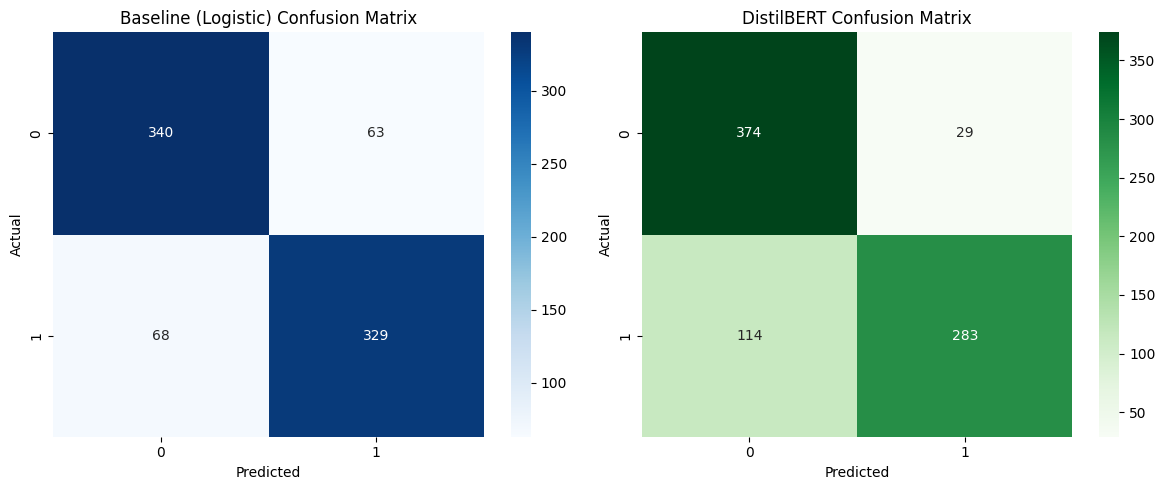

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a figure with two side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Baseline Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Baseline (Logistic) Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Plot 2: DistilBERT Confusion Matrix
sns.heatmap(confusion_matrix(y_test, bert_preds), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('DistilBERT Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Error Analysis and Model Disagreement

In [5]:
# Create a temporary dataframe to compare model mistakes
results_df = pd.DataFrame({
    'Review': X_test,
    'Actual': y_test,
    'Baseline_Pred': y_pred,
    'DistilBERT_Pred': bert_preds
})

# Find examples where Baseline was Correct (1) but DistilBERT was Wrong (0)
# These represent the "Pessimism" of the DistilBERT model
disagreements = results_df[(results_df['Actual'] == 1) & 
                           (results_df['Baseline_Pred'] == 1) & 
                           (results_df['DistilBERT_Pred'] == 0)]

print("Examples where DistilBERT was 'Too Pessimistic':")
print(disagreements['Review'].head(3).values)

Examples where DistilBERT was 'Too Pessimistic':
<StringArray>
[                                                                                                                                            'the aerogarden is an excellent product  the romaine lettuce seeds i am reviewing are doing very well so far  not so for the cherry tomato seeds  the several batches of cherry tomato seeds i have gotten will only grow so far and then seem to grow extremely slowly  none have produced any fruit i am doing much better with micro tom tomato seeds i have purchased from a seed company  i do highly recommend the romaine lettuce seeds however',
                                                                                                                                                                                                                                                                                                                                                                   